### Instancia Evaluación Clase 6 - Support Vector Machine y SGD

### Clasificación de tipos de vino utilizando modelos de aprendizaje supervisado 

En esta actividad se utilizará el Wine Dataset para aplicar dos modelos de clasificación vistos en clase: Support Vector Machine (SVM) y Stochastic Gradient Descent (SGDClassifier).  

El objetivo es comparar el rendimiento de ambos modelos y evaluar cuál resuelve mejor el problema de clasificación.

In [23]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Preparación de datos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos de clasificación
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier

# Métricas de evaluación
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


### Carga del dataset

In [5]:
# Nombres de las columnas del Wine Dataset
columnas = [
    "clase", "alcohol", "acido_malico", "ceniza", "alcalinidad_ceniza",
    "magnesio", "fenoles_totales", "flavonoides", "fenoles_no_flavonoides",
    "proantocianinas", "intensidad_color", "tono",
    "od280_od315", "prolina"
]

# Carga del dataset
df = pd.read_csv("wine.csv", header=None, names=columnas)

# Visualización de las primeras filas
df.head()

,clase,alcohol,acido_malico,ceniza,alcalinidad_ceniza,magnesio,fenoles_totales,flavonoides,fenoles_no_flavonoides,proantocianinas,intensidad_color,tono,od280_od315,prolina
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


### Exploración inicial de los datos

In [6]:
# Información general del dataset
print("Cantidad de filas y columnas:")
print(df.shape)

print("\nInformación del dataset:")
print(df.info())

print("\nValores faltantes:")
print(df.isnull().sum())

Cantidad de filas y columnas:
(178, 14)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   clase                   178 non-null    int64  
 1   alcohol                 178 non-null    float64
 2   acido_malico            178 non-null    float64
 3   ceniza                  178 non-null    float64
 4   alcalinidad_ceniza      178 non-null    float64
 5   magnesio                178 non-null    int64  
 6   fenoles_totales         178 non-null    float64
 7   flavonoides             178 non-null    float64
 8   fenoles_no_flavonoides  178 non-null    float64
 9   proantocianinas         178 non-null    float64
 10  intensidad_color        178 non-null    float64
 11  tono                    178 non-null    float64
 12  od280_od315             178 non-null    float64
 13  prolina                 178 n

### Visualización de datos

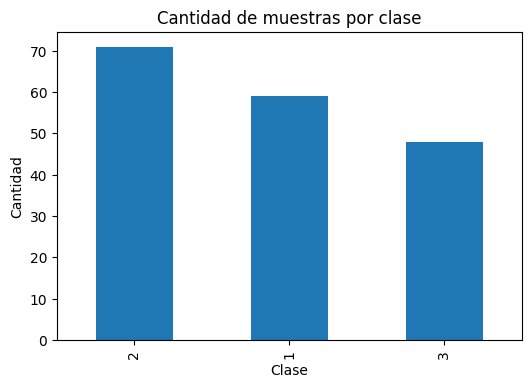

In [7]:
# Distribución de las clases
plt.figure(figsize=(6,4))

df["clase"].value_counts().plot(kind="bar")

plt.title("Cantidad de muestras por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad")

plt.show()

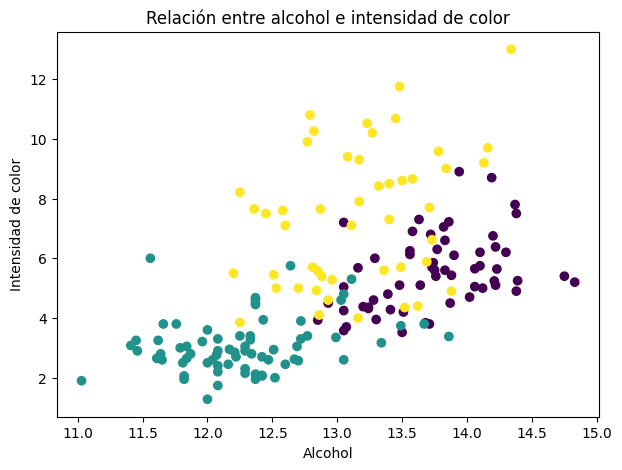

In [8]:
# Relación entre alcohol e intensidad de color
plt.figure(figsize=(7,5))

plt.scatter(
    df["alcohol"],
    df["intensidad_color"],
    c=df["clase"]
)

plt.title("Relación entre alcohol e intensidad de color")
plt.xlabel("Alcohol")
plt.ylabel("Intensidad de color")

plt.show()

### Separación de variables

In [9]:
# Variables predictoras
X = df.drop("clase", axis=1)

# Variable objetivo
y = df["clase"]

print("Variables predictoras:")
print(X.head())

print("\nVariable objetivo:")
print(y.head())

Variables predictoras:
   alcohol  acido_malico  ceniza  alcalinidad_ceniza  magnesio  \
0    14.23          1.71    2.43                15.6       127   
1    13.20          1.78    2.14                11.2       100   
2    13.16          2.36    2.67                18.6       101   
3    14.37          1.95    2.50                16.8       113   
4    13.24          2.59    2.87                21.0       118   

   fenoles_totales  flavonoides  fenoles_no_flavonoides  proantocianinas  \
0             2.80         3.06                    0.28             2.29   
1             2.65         2.76                    0.26             1.28   
2             2.80         3.24                    0.30             2.81   
3             3.85         3.49                    0.24             2.18   
4             2.80         2.69                    0.39             1.82   

   intensidad_color  tono  od280_od315  prolina  
0              5.64  1.04         3.92     1065  
1              4.38  1.

### División de datos en entrenamiento y prueba

In [10]:
# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (142, 13)
Datos de prueba: (36, 13)


### Escalado de datos

In [11]:
# Escalado de variables
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Escalado realizado correctamente")

Escalado realizado correctamente


### Modelo Support Vector Machine (SVM)

In [13]:
# Creación del modelo SVM
svm_model = SVC(kernel="linear")

# Entrenamiento del modelo
svm_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_svm = svm_model.predict(X_test_scaled)

print("Predicciones realizadas correctamente")

Predicciones realizadas correctamente


### Evaluación del modelo SVM

In [14]:
# Accuracy del modelo SVM
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Accuracy SVM:", accuracy_svm)

# Reporte de clasificación
print("\nReporte de clasificación SVM:")
print(classification_report(y_test, y_pred_svm))

Accuracy SVM: 0.9722222222222222

Reporte de clasificación SVM:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      0.93      0.96        14
           3       0.89      1.00      0.94         8

    accuracy                           0.97        36
   macro avg       0.96      0.98      0.97        36
weighted avg       0.98      0.97      0.97        36



### Matriz de confusión del modelo SVM

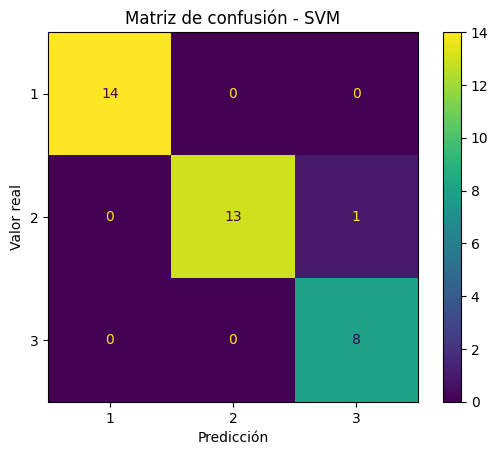

In [24]:
# Matriz de confusión visual - SVM
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)

plt.title("Matriz de confusión - SVM")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

### Modelo Stochastic Gradient Descent (SGDClassifier)

In [17]:
# Creación del modelo SGD
sgd_model = SGDClassifier(random_state=42)

# Entrenamiento del modelo
sgd_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_sgd = sgd_model.predict(X_test_scaled)

print("Predicciones realizadas correctamente")

Predicciones realizadas correctamente


### Evaluación del modelo SGDClassifier

In [19]:
# Accuracy del modelo SGD
accuracy_sgd = accuracy_score(y_test, y_pred_sgd)

print("Accuracy SGD:", accuracy_sgd)

# Reporte de clasificación
print("\nReporte de clasificación SGD:")
print(classification_report(y_test, y_pred_sgd))

Accuracy SGD: 0.9722222222222222

Reporte de clasificación SGD:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      0.93      0.96        14
           3       0.89      1.00      0.94         8

    accuracy                           0.97        36
   macro avg       0.96      0.98      0.97        36
weighted avg       0.98      0.97      0.97        36



### Matriz de confusión del modelo SGDClassifier

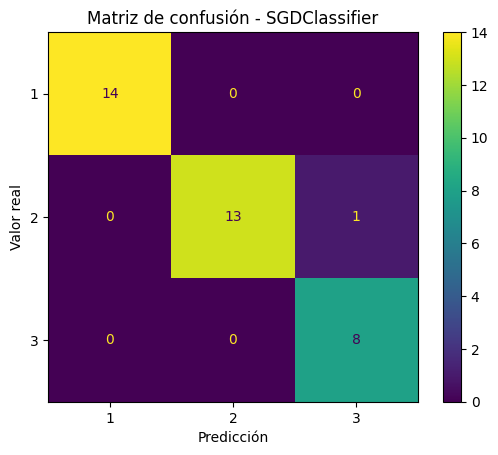

In [25]:
# Matriz de confusión visual - SGDClassifier
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_sgd)

plt.title("Matriz de confusión - SGDClassifier")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

### Comparación de los modelos

In [21]:
# Comparación de accuracy entre modelos
resultados = pd.DataFrame({
    "Modelo": ["SVM", "SGDClassifier"],
    "Accuracy": [accuracy_svm, accuracy_sgd]
})

resultados

,Modelo,Accuracy
0,SVM,0.972222
1,SGDClassifier,0.972222


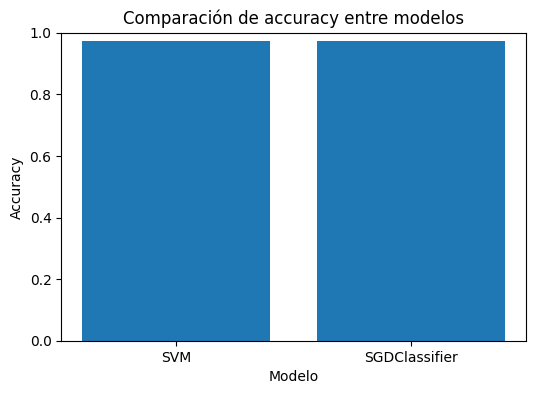

In [22]:
# Gráfico comparativo de accuracy
plt.figure(figsize=(6,4))

plt.bar(resultados["Modelo"], resultados["Accuracy"])

plt.title("Comparación de accuracy entre modelos")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

### Interpretación de la comparación

Ambos modelos obtuvieron un accuracy de 0.97, por lo tanto tuvieron un rendimiento muy similar en la clasificación del Wine Dataset.

Tanto SVM como SGDClassifier clasificaron correctamente la mayoría de los datos de prueba. La matriz de confusión muestra que solo hubo un error de clasificación en ambos modelos.

En este caso, no se observa una diferencia significativa entre los modelos según el accuracy obtenido.

### Conclusión

En esta actividad se trabajó con el Wine Dataset utilizando dos modelos de aprendizaje supervisado: Support Vector Machine (SVM) y SGDClassifier.

Primero se realizó la carga y exploración de los datos, verificando que el dataset no presentaba valores faltantes. Luego se aplicó un proceso de escalado para normalizar las variables antes del entrenamiento de los modelos.

Los resultados obtenidos mostraron que ambos modelos alcanzaron un accuracy aproximado de 97%, logrando clasificar correctamente la mayoría de las muestras del conjunto de prueba.

Las matrices de confusión permitieron visualizar que ambos modelos tuvieron un desempeño muy similar, con muy pocos errores de clasificación.

En conclusión, tanto SVM como SGDClassifier resultaron adecuados para resolver este problema de clasificación sobre el Wine Dataset.